# E-Commerce EDA & Business Analysis
Exploratory analysis on cleaned e-commerce data to answer key business questions around sales, profit, discounts, and customer behavior.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/ecommerce cleaned.csv")
df.head()

,Order_ID,Order_Date,Customer_ID,Product_Name,Category,Sub_Category,Quantity,Sales,Discount,Profit,City,State,Payment_Mode
0,ORD13379,01/01/2025,CUST03038,T-Shirt,Clothing,Men,1,845.0,0,61.98,Chennai,Tamil Nadu,UPI
1,ORD31029,01/01/2025,CUST05160,T-Shirt,Clothing,Men,3,2428.2,5,341.68,Vijayawada,Andhra Pradesh,Credit Card
2,ORD13421,01/01/2025,CUST05005,Dress,Clothing,Women,3,6976.8,5,1066.95,Chennai,Tamil Nadu,Debit Card
3,ORD01988,01/01/2025,CUST06475,Mixer Grinder,Home & Kitchen,Kitchen,4,14803.6,15,2723.54,Visakhapatnam,Andhra Pradesh,UPI
4,ORD23309,01/01/2025,CUST05030,Tablet,Electronics,Computers,1,19892.0,0,3160.95,Visakhapatnam,Andhra Pradesh,Cash on Delivery


In [5]:
df.describe()

,Quantity,Sales,Discount,Profit
count,40000.000000,40000.000000,40000.000000,40000.000000
mean,3.006500,20847.640462,7.751000,2924.471209
std,1.417554,41517.695854,5.577659,6228.085684
min,1.000000,269.600000,0.000000,19.930000
25%,2.000000,2628.000000,5.000000,352.060000
50%,3.000000,6655.500000,10.000000,861.255000
75%,4.000000,14556.150000,10.000000,2054.312500
max,5.000000,354169.500000,20.000000,70047.260000


In [6]:
df['Category'].value_counts()

,count
Category,
Beauty,10121
Clothing,10019
Home & Kitchen,10017
Electronics,9843


Q1. Which category generates the most revenue, and does it also give the best profit?

In [7]:
category_summary = df.groupby('Category').agg(
    Total_Sales=('Sales','sum'),
    Total_Profit=('Profit','sum')
)
category_summary['Profit_Margin_%'] = category_summary['Total_Profit']/category_summary['Total_Sales']*100
category_summary.sort_values('Total_Sales', ascending=False)

,Total_Sales,Total_Profit,Profit_Margin_%
Category,,,
Electronics,6.263464e+08,88018381.18,14.052667
Home & Kitchen,1.132201e+08,15728384.14,13.891869
Clothing,6.298497e+07,8859652.53,14.066297
Beauty,3.135413e+07,4372430.51,13.945308


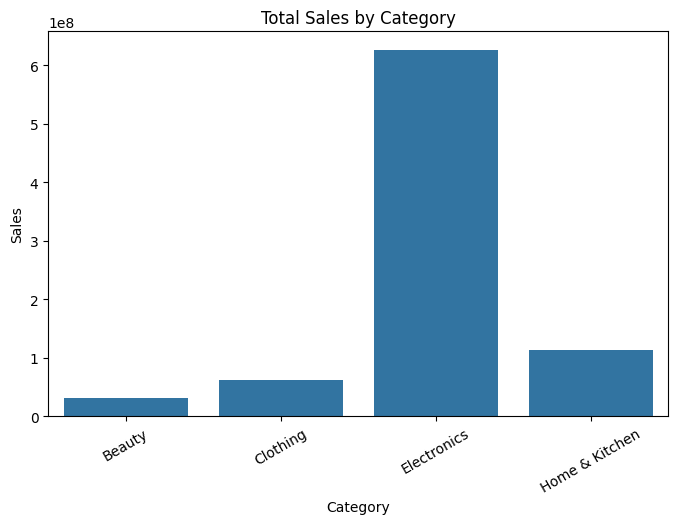

In [8]:
plt.figure(figsize=(8,5))
sns.barplot(x=category_summary.index, y=category_summary['Total_Sales'])
plt.title("Total Sales by Category")
plt.ylabel("Sales")
plt.xticks(rotation=30)
plt.show()

## Q2. Does giving more discount actually reduce profit?

In [9]:
discount_summary = df.groupby('Discount').agg(
    Avg_Sales=('Sales','mean'),
    Avg_Profit=('Profit','mean'),
    Orders=('Order_ID','count')
).sort_index()
discount_summary

,Avg_Sales,Avg_Profit,Orders
Discount,,,
0,22669.085943,3150.477484,7982
5,22201.603469,3101.731442,11991
10,19806.030007,2783.144036,12057
15,18675.265100,2649.754479,5977
20,18222.872052,2631.673457,1993


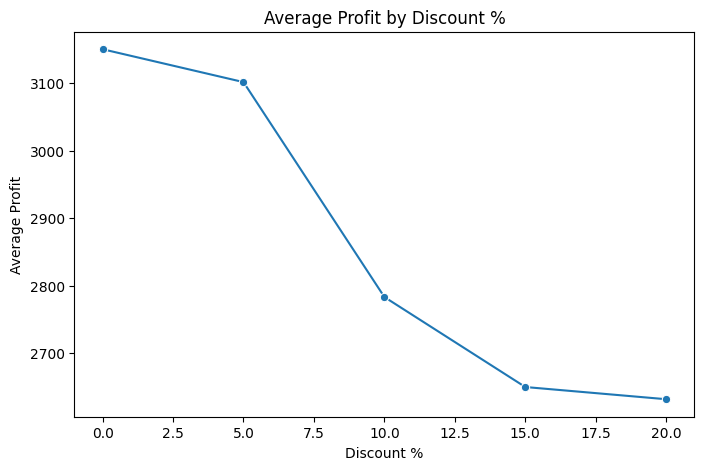

In [10]:
plt.figure(figsize=(8,5))
sns.lineplot(x=discount_summary.index, y=discount_summary['Avg_Profit'], marker='o')
plt.title("Average Profit by Discount %")
plt.xlabel("Discount %")
plt.ylabel("Average Profit")
plt.show()

## Q3. Which state generates the most profit, and where should the business focus expansion?

In [11]:
state_summary = df.groupby('State').agg(
    Total_Sales=('Sales','sum'),
    Total_Profit=('Profit','sum'),
    Orders=('Order_ID','count')
).sort_values('Total_Profit', ascending=False)
state_summary

,Total_Sales,Total_Profit,Orders
State,,,
Andhra Pradesh,2.102114e+08,29547122.58,10063
Maharashtra,2.032381e+08,28304998.25,9794
Delhi,1.082986e+08,15343827.62,5157
Tamil Nadu,1.067314e+08,15120334.65,5084
Telangana,1.079576e+08,15041958.87,5010
Karnataka,9.746845e+07,13620606.39,4892


/tmp/ipykernel_2840/1408353243.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_summary['Total_Profit'], y=state_summary.index, palette='viridis')


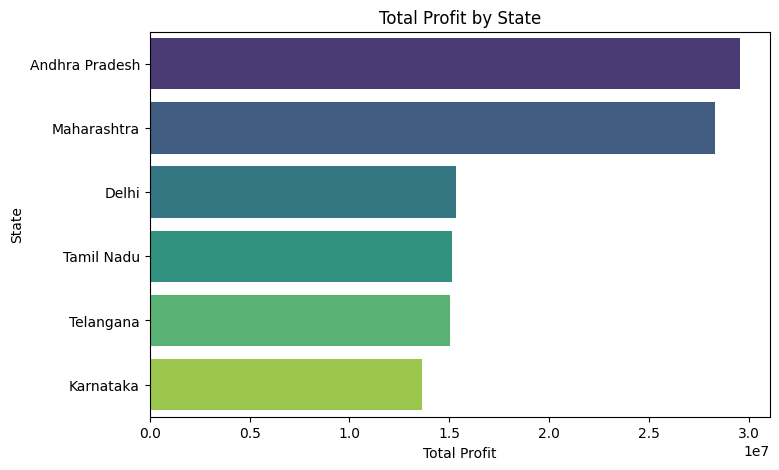

In [12]:
plt.figure(figsize=(8,5))
sns.barplot(x=state_summary['Total_Profit'], y=state_summary.index, palette='viridis')
plt.title("Total Profit by State")
plt.xlabel("Total Profit")
plt.ylabel("State")
plt.show()

## Q4. Are there any unusually high-value orders that need review?

In [13]:
Q1_val = np.percentile(df['Sales'], 25)
Q3_val = np.percentile(df['Sales'], 75)
IQR = Q3_val - Q1_val

upper_limit = Q3_val + 1.5 * IQR
outliers = df[df['Sales'] > upper_limit]

print(f"Number of outlier orders: {len(outliers)}")
outliers[['Order_ID','Sales','Profit','Category']].head()

Number of outlier orders: 5762


,Order_ID,Sales,Profit,Category
18,ORD19291,77028.30,16077.00,Electronics
43,ORD34873,69615.00,10783.41,Electronics
44,ORD38508,81252.00,11575.87,Electronics
58,ORD06931,80275.95,16580.17,Electronics
67,ORD34587,46559.70,5257.00,Electronics


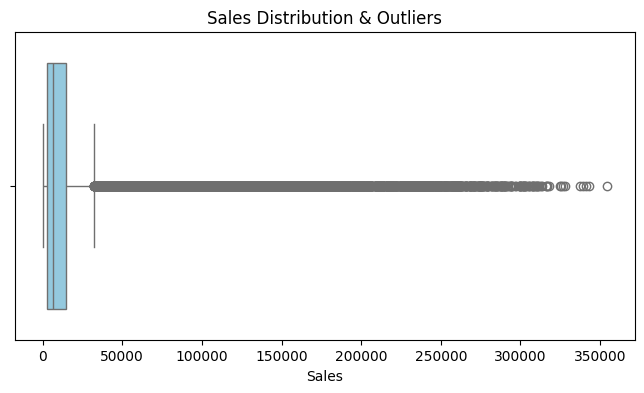

In [14]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Sales'], color='skyblue')
plt.title("Sales Distribution & Outliers")
plt.xlabel("Sales")
plt.show()

Q5. How do customers prefer to pay — which payment mode is most used?

In [15]:
payment_summary = df['Payment_Mode'].value_counts()
payment_summary

,count
Payment_Mode,
UPI,8124
Net Banking,8109
Debit Card,8054
Cash on Delivery,7960
Credit Card,7753


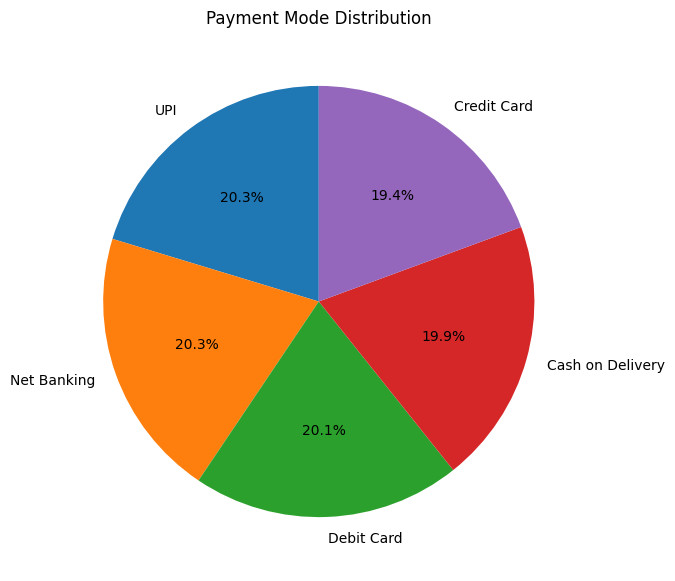

In [16]:
plt.figure(figsize=(7,7))
plt.pie(payment_summary, labels=payment_summary.index, autopct='%1.1f%%', startangle=90)
plt.title("Payment Mode Distribution")
plt.show()

## Q6. Which months have the highest sales, and is there a seasonal pattern?

In [21]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d/%m/%Y')
df['Month'] = df['Order_Date'].dt.month_name()

monthly_summary = df.groupby('Month')['Sales'].sum()
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly_summary = monthly_summary.reindex(month_order)
monthly_summary

,Sales
Month,
January,93247894.10
February,91557042.15
March,88178772.55
April,87583862.35
May,92833260.75
June,93816970.35
July,45772682.95
August,46949640.55
September,48771038.70


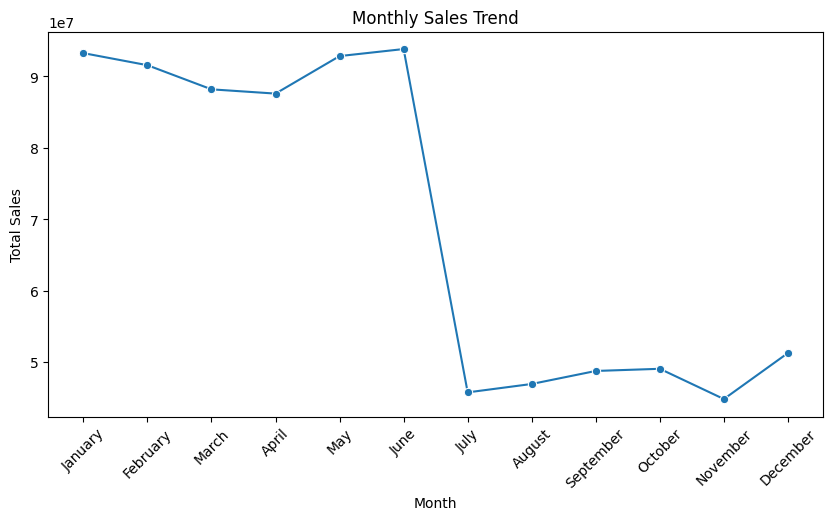

In [22]:
plt.figure(figsize=(10,5))
sns.lineplot(x=monthly_summary.index, y=monthly_summary.values, marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()